In [40]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, StandardScaler
from sklearn.utils import shuffle

In [41]:
df = pd.read_csv("../data/processed/engineered_dataset.csv")

df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

print(df.shape)

(5600, 19)


In [42]:
features = [
    'failure_rate',
    'port_scan_intensity',
    'process_cpu_ratio',
    'packet_spike_ratio',
    'connection_spike_ratio',
    'cpu_spike_ratio'
]

X = df[features]
y = df['attack_type']

In [43]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'crypto': np.int64(0), 'ddos': np.int64(1), 'none': np.int64(2), 'portscan': np.int64(3)}


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [45]:
# Apply log transform ONLY on train → then apply same to test

for col in ['process_cpu_ratio', 'packet_spike_ratio', 'connection_spike_ratio']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,          # prevent overfitting
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [48]:
y_pred = model.predict(X_test)

In [49]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Confusion Matrix:

[[ 99   0   1   0]
 [  0 120   0   0]
 [  0   0 780   0]
 [  0   0   0 120]]

Classification Report:

              precision    recall  f1-score   support

      crypto       1.00      0.99      0.99       100
        ddos       1.00      1.00      1.00       120
        none       1.00      1.00      1.00       780
    portscan       1.00      1.00      1.00       120

    accuracy                           1.00      1120
   macro avg       1.00      1.00      1.00      1120
weighted avg       1.00      1.00      1.00      1120



In [50]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Train Accuracy: 0.9996
Test Accuracy : 0.9991


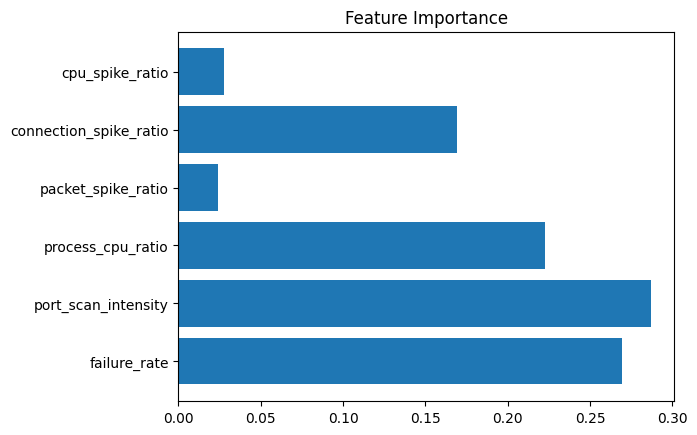

In [51]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [52]:
# Evaluate ONLY on attacks
attack_mask = df['attack_type'] != 'none'
X_attack = X[attack_mask]
y_attack = y_encoded[attack_mask]

X_attack_scaled = scaler.transform(X_attack)
attack_labels = [i for i, label in enumerate(le.classes_) if label != 'none']
attack_names = [label for label in le.classes_ if label != 'none']

y_pred_attack = model.predict(X_attack_scaled)

print("Attack-only classification report:")
print(classification_report(
    y_attack,
    y_pred_attack,
    labels=attack_labels,
    target_names=attack_names
))
print(f"Attack-only accuracy: {np.mean(y_pred_attack == y_attack):.4f}")

Attack-only classification report:
              precision    recall  f1-score   support

      crypto       1.00      0.99      1.00       500
        ddos       1.00      1.00      1.00       600
    portscan       1.00      1.00      1.00       600

   micro avg       1.00      1.00      1.00      1700
   macro avg       1.00      1.00      1.00      1700
weighted avg       1.00      1.00      1.00      1700

Attack-only accuracy: 0.9982


Test without "process_cpu_ratio" to check whether one feature is dominating the signal.

In [53]:
features_test = [
    'failure_rate',
    'port_scan_intensity',
    'packet_spike_ratio',
    'connection_spike_ratio',
    'cpu_spike_ratio'
]

X_reduced = df[features_test]
y_reduced = y_encoded

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

for col in ['packet_spike_ratio', 'connection_spike_ratio']:
    X_train_red[col] = np.log1p(X_train_red[col])
    X_test_red[col] = np.log1p(X_test_red[col])

scaler_red = StandardScaler()
X_train_red = scaler_red.fit_transform(X_train_red)
X_test_red = scaler_red.transform(X_test_red)

model_reduced = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42
)
model_reduced.fit(X_train_red, y_train_red)

y_pred_reduced = model_reduced.predict(X_test_red)

print("Reduced-feature classification report:")
print(classification_report(y_test_red, y_pred_reduced, target_names=le.classes_))
print(f"Reduced-feature test accuracy: {np.mean(y_pred_reduced == y_test_red):.4f}")


Reduced-feature classification report:
              precision    recall  f1-score   support

      crypto       0.93      0.94      0.94       100
        ddos       1.00      1.00      1.00       120
        none       0.99      0.99      0.99       780
    portscan       1.00      1.00      1.00       120

    accuracy                           0.99      1120
   macro avg       0.98      0.98      0.98      1120
weighted avg       0.99      0.99      0.99      1120

Reduced-feature test accuracy: 0.9884


In [38]:
def log_transform_input(X_input):
    X_df = pd.DataFrame(X_input, columns=features)
    X_df[['process_cpu_ratio', 'packet_spike_ratio', 'connection_spike_ratio']] = np.log1p(
        X_df[['process_cpu_ratio', 'packet_spike_ratio', 'connection_spike_ratio']]
    )
    return X_df.values

pipeline = Pipeline([
    ('log', FunctionTransformer(log_transform_input, validate=False)),
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42))
])

scores = cross_val_score(
    pipeline,
    X,
    y_encoded,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean CV:", scores.mean())


CV Scores: [0.99553571 1.         0.99732143 0.99732143 1.        ]
Mean CV: 0.9980357142857142


In [54]:
# Shuffle labels as a leakage / permutation test
y_shuffled = shuffle(y_encoded, random_state=42)
scores_shuffled = cross_val_score(
    pipeline,
    X,
    y_shuffled,
    cv=5,
    scoring='accuracy'
)

print("Shuffled-label CV Scores:", scores_shuffled)
print("Mean shuffled-label CV:", scores_shuffled.mean())

# If this stays near the original CV level, there is likely leakage.
# If it drops near chance (around 0.25 for 4 classes), the original signal is likely real.


Shuffled-label CV Scores: [0.37142857 0.69642857 0.69642857 0.69642857 0.69642857]
Mean shuffled-label CV: 0.6314285714285713


In [55]:
import pandas as pd

df_temp = pd.DataFrame(X, columns=features)
df_temp['y'] = y_encoded

print(df_temp.groupby('y').mean())

   failure_rate  port_scan_intensity  process_cpu_ratio  packet_spike_ratio  \
y                                                                             
0      0.000000             0.000000       50986.835400            0.900669   
1      0.115944             0.000000           0.001347            1.027723   
2      0.000000             0.034059           0.023368            0.978410   
3      0.000000             2.079050           0.004354            1.023718   

   connection_spike_ratio  cpu_spike_ratio  
y                                           
0                1.004252         1.009725  
1                1.024531         1.014430  
2                1.000025         1.001772  
3                1.012086         1.001690  


The dataset exhibits strong feature-class correlations, making classification straightforward. However, real-world environments may introduce noise and overlapping behavior, requiring more robust models.

OPTIONAL->if needed to look extra smart
Introduce slight noise:
df_noisy = df.copy()
df_noisy[features] += np.random.normal(0, 0.01, df_noisy[features].shape)